In [ ]:
!pip install "numpy<2"
!pip install scikit-surprise
!pip install sentence-transformers
# KHAI BÁO THƯ VIỆN
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel, cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from surprise import Reader, Dataset, SVD, accuracy
from surprise.model_selection import train_test_split
from sentence_transformers import SentenceTransformer # Thêm thư viện Deep Learning
from google.colab import files
import math

  Using cached scikit_surprise-1.1.5-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (15 kB)
Using cached scikit_surprise-1.1.5-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (3.1 MB)


In [ ]:

# 1: ĐỌC VÀ TIỀN XỬ LÝ DỮ LIỆU

print("1. Đang tải và dọn dẹp dữ liệu...")

# Xử lý Anime
anime_df = pd.read_csv('/content/drive/MyDrive/Hybrid Anime Recommender System/anime-filtered.csv')
anime_df = anime_df.rename(columns={'Name': 'name', 'Genres': 'genre'})

# Điền giá trị rỗng cho các cột Text
anime_df['genre'] = anime_df['genre'].fillna('')
anime_df['sypnopsis'] = anime_df['sypnopsis'].fillna('')

# Xử lý Rating (Dùng 2 triệu dòng, ép kiểu để tối ưu RAM)
rating_df = pd.read_csv('/content/drive/MyDrive/Hybrid Anime Recommender System/user-filtered.csv',
                        nrows=2000000,
                        dtype={'user_id': 'int32', 'anime_id': 'int32', 'rating': 'int8'})

# Xóa điểm 0 (Người dùng lưu phim nhưng lười chấm điểm)
rating_df = rating_df[rating_df['rating'] > 0]

# Lọc dữ liệu thưa (Chỉ lấy User > 50 phim và Anime > 50 lượt vote)
min_anime_ratings = 50
filter_animes = rating_df['anime_id'].value_counts() > min_anime_ratings
filter_animes = filter_animes[filter_animes].index.tolist() # mang gom nhung id user > 50 phim

min_user_ratings = 50
filter_users = rating_df['user_id'].value_counts() > min_user_ratings
filter_users = filter_users[filter_users].index.tolist()

rating_df_clean = rating_df[(rating_df['anime_id'].isin(filter_animes)) & (rating_df['user_id'].isin(filter_users))]
print(f"-> Tổng số rating tinh khiết để train AI: {len(rating_df_clean)}")

1. Đang tải và dọn dẹp dữ liệu...
-> Tổng số rating tinh khiết để train AI: 1019961


In [ ]:

# 2: HUẤN LUYỆN CONTENT-BASED (CẢ 2 MÔ HÌNH)

print("\n2. Đang xây dựng hệ thống đặc trưng (Text & Heuristics)...")

valid_anime_ids = rating_df_clean['anime_id'].unique()
anime_df = anime_df[anime_df['anime_id'].isin(valid_anime_ids)].copy()

# Tạo Nồi lẩu văn bản
anime_df['metadata_soup'] = anime_df['genre'] + " " + anime_df['genre'] + " " + anime_df['sypnopsis']

# --- MÔ HÌNH 1: CỔ ĐIỂN (TF-IDF) ---
print("-> Đang huấn luyện TF-IDF (Classic)...")
tf = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=2, stop_words='english')
tfidf_matrix = tf.fit_transform(anime_df['metadata_soup']) # Một ma trận toán học khổng lồ toàn số thập phân. Mỗi hàng là 1 anime, mỗi cột là 1 từ khoá, giá trị là điểm số TF-IDF.
tfidf_cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix) # đưa vào 2 lần để nó tự lấy từng anime so sánh với toàn bộ các anime còn lại

# --- MÔ HÌNH 2: DEEP LEARNING (SENTENCE-BERT) ---
print("-> Đang huấn luyện Deep Learning (Sentence-BERT)... Có thể mất 2-3 phút.")
# Dùng model 'all-MiniLM-L6-v2' (Nhỏ, nhẹ, chạy cực nhanh nhưng rất thông minh)
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
# Biến 10.000 đoạn tóm tắt thành Ma trận Vector đa chiều
bert_embeddings = bert_model.encode(anime_df['metadata_soup'].tolist(), show_progress_bar=True)
# Tính độ tương đồng Cosine trên Vector của BERT
bert_cosine_sim = cosine_similarity(bert_embeddings, bert_embeddings)

# --- XỬ LÝ CHỈ SỐ STATS ---
anime_df['Score'] = anime_df['Score'].fillna(0)
anime_df['Dropped'] = anime_df['Dropped'].fillna(0)
anime_df['Members'] = anime_df['Members'].replace(0, 1)
anime_df['drop_rate'] = anime_df['Dropped'] / anime_df['Members']

scaler = MinMaxScaler() # Chuẩn hóa Score (Scale từ 1-10 về khoảng 0-1 để dễ tính toán)
anime_df['normalized_score'] = scaler.fit_transform(anime_df[['Score']])
anime_df['quality_weight'] = 1.0 + (anime_df['normalized_score'] * 0.2) - (anime_df['drop_rate'] * 1.5) # quality_weight để thưởng điểm cho phim Rate cao và trừ điểm phim Drop nhiều.
anime_df['quality_weight'] = anime_df['quality_weight'].clip(lower=0.5) #clip : chặn giá trị min = 0.5

# --- TẠO TỪ ĐIỂN TRA CỨU ---
anime_df = anime_df.reset_index(drop=True)
id_to_index = pd.Series(anime_df.index, index=anime_df['anime_id'])


2. Đang xây dựng hệ thống đặc trưng (Text & Heuristics)...
-> Đang huấn luyện TF-IDF (Classic)...
-> Đang huấn luyện Deep Learning (Sentence-BERT)... Có thể mất 2-3 phút.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/110 [00:00<?, ?it/s]

In [ ]:
# 3: HUẤN LUYỆN SVD & ĐO LƯỜNG TOÀN HỆ THỐNG

print("\n3. Đang huấn luyện SVD và đo sai số hệ thống...")
reader = Reader(rating_scale=(1, 10))
data = Dataset.load_from_df(rating_df_clean[['user_id', 'anime_id', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

svd_model = SVD(n_epochs=30, lr_all=0.005, reg_all=0.1, verbose=False)
        #lr_all=0.005 (Learning Rate): AI sẽ tự điều chỉnh bản thân sau mỗi lần đoán sai. Số này quy định nó sửa sai chậm hay nhanh. Lớn quá thì "ảo tưởng", nhỏ quá thì học quá lâu.
        #reg_all=0.1 (Regularization - Phạt học vẹt): Ngăn chặn thuật toán dự đoán các mức điểm vô lý (ví dụ đoán điểm 15/10), giúp nó khiêm tốn và bám sát thực tế hơn.
svd_model.fit(trainset)
        # Đoán xem người dùng số 15 sẽ chấm phim số 101 mấy điểm
        # ket_qua = svd_model.predict(uid=15, iid=101) # 9.999

# 3.1: Sai số SVD độc lập
svd_predictions = svd_model.test(testset)
print(f"-> RMSE (Chỉ dùng SVD): {accuracy.rmse(svd_predictions, verbose=False):.4f}")


3. Đang huấn luyện SVD và đo sai số hệ thống...
-> RMSE (Chỉ dùng SVD): 1.2092


In [ ]:

# 3.2: TÍNH SAI SỐ HYBRID CHO CẢ 2 MÔ HÌNH (BERT VÀ TF-IDF)
print("-> Đang tính toán Hybrid RMSE cho cả 2 Engine (Khoảng 10.000 mẫu ngẫu nhiên)...")
sample_testset = testset[:10000]

# Khởi tạo 2 mảng lưu sai số riêng biệt
hybrid_errors_bert = []
hybrid_errors_tfidf = []

# Trích xuất user ratings từ tập Train (để làm lịch sử cho Content-Based)
user_history = {}
        # user_history = {
        #     "user_1": {"anime_101": 9.0, "anime_202": 8.0, "anime_303": 10.0},
        #     "user_2": {"anime_101": 7.0, "anime_999": 6.0},
        #     # ... hàng ngàn user khác
        # }
for uid, iid, r in trainset.all_ratings(): #User ID, Item ID, rating
    raw_user = trainset.to_raw_uid(uid) # from Inner ID (12345) to RawID (hieudao)
    raw_item = trainset.to_raw_iid(iid)
    if raw_user not in user_history: user_history[raw_user] = {}
    user_history[raw_user][raw_item] = r

for uid, iid, actual_rating in sample_testset:
    # Điểm 1: SVD (Chuyên gia đoán điểm - Dùng chung cho cả 2)
    svd_est = svd_model.predict(uid, iid).est
            # svd_model.predict(uid, iid) = Prediction(uid='hieu_dao', iid=20, r_ui=None, est=8.5, details={'was_impossible': False})
    # Khởi tạo điểm Content-based mặc định (Fallback)
    cb_est_bert = svd_est
    cb_est_tfidf = svd_est

    if uid in user_history and iid in id_to_index:
        target_idx = id_to_index[iid] # iid = 999 => target_idx = 5

        sim_rating_pairs_bert = []
        sim_rating_pairs_tfidf = []

        # Quét qua lịch sử xem của user để lấy độ tương đồng
        for watched_id, watched_rating in user_history[uid].items():
            if watched_id in id_to_index:
                watched_idx = id_to_index[watched_id]

                # Trích xuất độ tương đồng từ 2 ma trận khác nhau
                sim_bert = bert_cosine_sim[target_idx][watched_idx]
                sim_tfidf = tfidf_cosine_sim[target_idx][watched_idx]

                # Điều kiện lọc: BERT ( > 0.1 ), TF-IDF ( > 0.0 )
                if sim_bert > 0.1:
                    sim_rating_pairs_bert.append((sim_bert, watched_rating))
                if sim_tfidf > 0.0:
                    sim_rating_pairs_tfidf.append((sim_tfidf, watched_rating))

        # --- XỬ LÝ ĐIỂM CHO BERT (K=5) ---
        sim_rating_pairs_bert.sort(key=lambda x: x[0], reverse=True)
        top_5_bert = sim_rating_pairs_bert[:5]
        if len(top_5_bert) > 0:
            sim_sum = sum([pair[0] for pair in top_5_bert]) # Tổng các lực lượng độ giống
            weighted_rating_sum = sum([pair[0] * pair[1] for pair in top_5_bert]) # (Độ giống * Điểm user chấm)
            cb_est_bert = weighted_rating_sum / sim_sum

        # --- XỬ LÝ ĐIỂM CHO TF-IDF (K=5) ---
        sim_rating_pairs_tfidf.sort(key=lambda x: x[0], reverse=True)
        top_5_tfidf = sim_rating_pairs_tfidf[:5]
        if len(top_5_tfidf) > 0:
            sim_sum = sum([pair[0] for pair in top_5_tfidf])
            weighted_rating_sum = sum([pair[0] * pair[1] for pair in top_5_tfidf])
            cb_est_tfidf = weighted_rating_sum / sim_sum


    # LAI GHÉP & TÍNH SAI SỐ BÌNH PHƯƠNG

    # 1. Engine Deep Learning (80% SVD + 20% BERT)
    hybrid_est_bert = (svd_est * 0.8) + (cb_est_bert * 0.2)
    hybrid_errors_bert.append((actual_rating - hybrid_est_bert) ** 2)

    # 2. Engine Classic (50% SVD + 50% TF-IDF)
    hybrid_est_tfidf = (svd_est * 0.5) + (cb_est_tfidf * 0.5)
    hybrid_errors_tfidf.append((actual_rating - hybrid_est_tfidf) ** 2)

# Tổng hợp RMSE
rmse_bert = math.sqrt(sum(hybrid_errors_bert) / len(hybrid_errors_bert))
rmse_tfidf = math.sqrt(sum(hybrid_errors_tfidf) / len(hybrid_errors_tfidf))

print("\n--- BÁO CÁO SAI SỐ TOÀN HỆ THỐNG ---")
print(f"-> 1. RMSE Độc lập (Chỉ SVD)                : {accuracy.rmse(svd_predictions, verbose=False):.4f}")
print(f"-> 2. RMSE Hybrid (Deep Learning: BERT+SVD): {rmse_bert:.4f}")
print(f"-> 3. RMSE Hybrid (Classic: TF-IDF + SVD)  : {rmse_tfidf:.4f}")
print("-----------------------------------------")

-> Đang tính toán Hybrid RMSE cho cả 2 Engine (Khoảng 10.000 mẫu ngẫu nhiên)...

--- BÁO CÁO SAI SỐ TOÀN HỆ THỐNG ---
-> 1. RMSE Độc lập (Chỉ SVD)                : 1.2092
-> 2. RMSE Hybrid (Deep Learning: BERT+SVD): 1.2271
-> 3. RMSE Hybrid (Classic: TF-IDF + SVD)  : 1.2603
-----------------------------------------


In [ ]:

# 4: XUẤT CÁC FILE ĐỂ ĐEM XUỐNG BACKEND

print("\n4. Đang xuất file .pkl và tải về máy...")
import pickle
from google.colab import files # Bắt buộc phải import cái này để tải về

# 1. Lưu các model ra file
with open('svd_model.pkl', 'wb') as f:
    pickle.dump(svd_model, f)

with open('tfidf_cosine_sim.pkl', 'wb') as f: # File của mô hình cũ
    pickle.dump(tfidf_cosine_sim, f)

with open('bert_cosine_sim.pkl', 'wb') as f:  # File của Deep Learning (Mới)
    pickle.dump(bert_cosine_sim, f)

# 2. Đóng gói Dataframe (LƯU Ý: Phải kẹp thêm cột quality_weight vào)
anime_artifacts = {
    'dataframe': anime_df[['anime_id', 'name', 'genre', 'quality_weight']],
    'id_to_index': id_to_index
}
with open('anime_artifacts.pkl', 'wb') as f:
    pickle.dump(anime_artifacts, f)

# 3. Kích hoạt trình duyệt tải 4 file xuống
print("Đang kích hoạt tải về...")
files.download('svd_model.pkl')
files.download('tfidf_cosine_sim.pkl')
files.download('bert_cosine_sim.pkl')
files.download('anime_artifacts.pkl')



4. Đang xuất file .pkl và tải về máy...
Đang kích hoạt tải về...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


3. Đang huấn luyện SVD và chuẩn bị vẽ biểu đồ Overfitting...
Đang chạy vòng lặp tính toán (Sẽ mất khoảng 1-2 phút)...
Epoch 5: Train RMSE = 1.1945 | Test RMSE = 1.2719
Epoch 10: Train RMSE = 1.0273 | Test RMSE = 1.2308
Epoch 15: Train RMSE = 0.8737 | Test RMSE = 1.2335
Epoch 20: Train RMSE = 0.7639 | Test RMSE = 1.2506
Epoch 25: Train RMSE = 0.6921 | Test RMSE = 1.2663
Epoch 30: Train RMSE = 0.6439 | Test RMSE = 1.2800
Epoch 35: Train RMSE = 0.6100 | Test RMSE = 1.2917
Epoch 40: Train RMSE = 0.5829 | Test RMSE = 1.3012
Epoch 45: Train RMSE = 0.5627 | Test RMSE = 1.3101
Epoch 50: Train RMSE = 0.5474 | Test RMSE = 1.3129
Epoch 60: Train RMSE = 0.5244 | Test RMSE = 1.3259


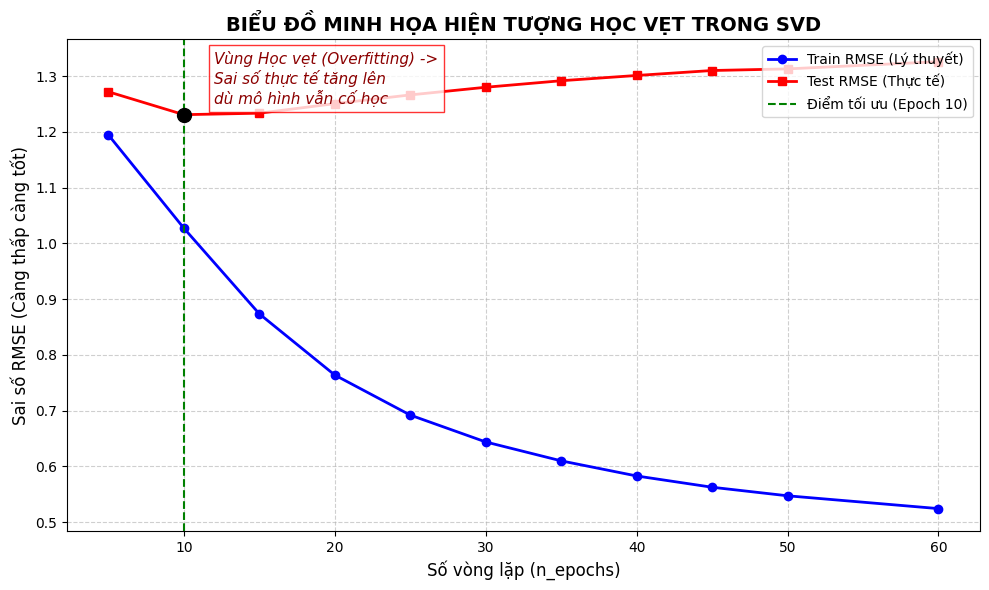


-> Bạn hãy chụp lại biểu đồ này đưa vào Báo cáo!


In [ ]:
# import matplotlib.pyplot as plt
# from surprise import Reader, Dataset, SVD, accuracy
# from surprise.model_selection import train_test_split

# print("\n3. Đang huấn luyện SVD và chuẩn bị vẽ biểu đồ Overfitting...")
# reader = Reader(rating_scale=(1, 10))
# data = Dataset.load_from_df(rating_df_clean[['user_id', 'anime_id', 'rating']], reader)
# trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# # Chuyển tập Train thành định dạng testset để hàm accuracy.rmse có thể đo được
# trainset_for_testing = trainset.build_testset()

# # Các mốc epochs để vẽ biểu đồ (Nhảy bước 5 để code chạy lẹ hơn)
# epochs_to_test = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60]
# train_rmse_list = []
# test_rmse_list = []

# print("Đang chạy vòng lặp tính toán (Sẽ mất khoảng 1-2 phút)...")
# for epoch in epochs_to_test:
#     # LƯU Ý: Hạ reg_all=0.02 để cố tình tạo ra hiện tượng Overfitting cho dễ thấy trên biểu đồ
#     algo = SVD(n_epochs=epoch, lr_all=0.005, reg_all=0.02, verbose=False)
#     algo.fit(trainset)

#     # Đo lỗi trên tập Train (Bài tập ở nhà)
#     train_preds = algo.test(trainset_for_testing)
#     train_rmse = accuracy.rmse(train_preds, verbose=False)
#     train_rmse_list.append(train_rmse)

#     # Đo lỗi trên tập Test (Đi thi thật)
#     test_preds = algo.test(testset)
#     test_rmse = accuracy.rmse(test_preds, verbose=False)
#     test_rmse_list.append(test_rmse)

#     print(f"Epoch {epoch}: Train RMSE = {train_rmse:.4f} | Test RMSE = {test_rmse:.4f}")

# # --- PHẦN VẼ BIỂU ĐỒ BẰNG MATPLOTLIB ---

# # 1. Tìm điểm 'Vừa tới' (Optimal Point - Nơi Test RMSE thấp nhất)
# min_test_rmse = min(test_rmse_list)
# optimal_idx = test_rmse_list.index(min_test_rmse)
# optimal_epoch = epochs_to_test[optimal_idx]

# # 2. Setup khung vẽ
# plt.figure(figsize=(10, 6))

# # 3. Vẽ 2 đường Train và Test
# plt.plot(epochs_to_test, train_rmse_list, label='Train RMSE (Lý thuyết)', marker='o', color='blue', linewidth=2)
# plt.plot(epochs_to_test, test_rmse_list, label='Test RMSE (Thực tế)', marker='s', color='red', linewidth=2)

# # 4. Vẽ đường cắt dọc (Vạch đích 'Vừa tới')
# plt.axvline(x=optimal_epoch, color='green', linestyle='--', linewidth=1.5,
#             label=f'Điểm tối ưu (Epoch {optimal_epoch})')

# # 5. Đánh dấu cái "Đáy"
# plt.scatter(optimal_epoch, min_test_rmse, color='black', s=100, zorder=5)

# # 6. Thêm Text chú thích vùng Học vẹt
# plt.text(optimal_epoch + 2, min_test_rmse + 0.02,
#          'Vùng Học vẹt (Overfitting) ->\nSai số thực tế tăng lên\ndù mô hình vẫn cố học',
#          color='darkred', fontsize=11, style='italic',
#          bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))

# # 7. Trang trí tên trục và Tiêu đề
# plt.title('BIỂU ĐỒ MINH HỌA HIỆN TƯỢNG HỌC VẸT TRONG SVD', fontsize=14, fontweight='bold')
# plt.xlabel('Số vòng lặp (n_epochs)', fontsize=12)
# plt.ylabel('Sai số RMSE (Càng thấp càng tốt)', fontsize=12)
# plt.legend(loc='upper right')
# plt.grid(True, linestyle='--', alpha=0.6)

# # Xuất hình ra màn hình Colab
# plt.tight_layout()
# plt.show()

# print("\n-> Bạn hãy chụp lại biểu đồ này đưa vào Báo cáo!")